# Comparing AI, Human, Fake and Real text

**Project question.** Does AI-generated text pattern more like reliable journalism or more like misinformation?

**Approach.** Build a unified four-group dataset (AI, Human, Fake, Real), compute 12 interpretable stylometric features on length-normalised windows, then triangulate the answer with three independent methods: centroid distance, classifier transfer, and PCA.

**Headline result.** AI text sits closer to Real news than to Fake news on both centroid distance (3.25 vs 3.32) and classifier transfer (75.9% of AI texts classified as Real-style). The directional finding is consistent across all three methods. The ethical implication, developed in Part 5 below, is **credibility laundering, not stylistic exposure**.


### 1. Data loading and group construction

**Question.** Can we bring the four heterogeneous text groups (AI, Human, Fake, Real) into a single comparable dataframe?

**Method.** Load the cleaned HC3 and ISOT outputs, relabel the four classes into a single `group` column, drop near-empty rows below 20 words.

**Finding.** Four working groups with substantial size imbalance: Real (20,819), Fake (17,087), AI (4,752), Human (4,675). The imbalance is real and we handle it later via Welch's t-test and per-group sampling for visualisations.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from collections import Counter

hc3 = pd.read_csv('hc3_clean.csv')
isot = pd.read_csv('isot_clean.csv')

# Build one unified dataframe with a consistent text column and a group label
ai     = hc3[hc3['label'] == 'ai'][['text']].copy();          ai['group'] = 'AI'
human  = hc3[hc3['label'] == 'human'][['text']].copy();       human['group'] = 'Human'
fake   = isot[isot['label'] == 'fake'][['text_clean']].rename(columns={'text_clean':'text'}); fake['group'] = 'Fake'
real   = isot[isot['label'] == 'real'][['text_clean']].rename(columns={'text_clean':'text'}); real['group'] = 'Real'

df = pd.concat([ai, human, fake, real], ignore_index=True)
df['text'] = df['text'].astype(str)
df = df[df['text'].str.split().str.len() >= 20].reset_index(drop=True)  # drop near-empty rows
print(df['group'].value_counts())

group
Real     20819
Fake     17087
AI        4752
Human     4675
Name: count, dtype: int64


### 2. Length normalisation

**Question.** How do we compare HC3 short answers against ISOT long-form articles without raw length itself becoming the dominant signal?

**Method.** Truncate every text to the first 120 words. 120 is roughly the length of a typical HC3 answer or the opening of a news article, so the comparison runs on equivalent windows.

**Finding.** All four groups now compete on equal footing. Any stylistic difference detected from this point onward cannot be explained by raw length, which is the single most important methodological move in the analysis.


In [3]:
WINDOW = 120  # words; ~ the length of a short news article or a HC3 answer

def truncate(text, n=WINDOW):
    return ' '.join(str(text).split()[:n])

df['text_trunc'] = df['text'].apply(truncate)

### 3. Stylometric feature engineering

**Question.** Which interpretable, basic-Python features capture writing style across the four groups?

**Method.** Twelve features computed per truncated text: word and sentence length, sentence-length standard deviation (burstiness), type-token ratio (lexical diversity), comma rate, punctuation rate, digit and uppercase rates, function-word rate, hedge rate, quote rate, and long-word rate.

**Finding.** A 12-dimensional stylometric fingerprint per document. Every feature is interpretable in plain language, which matters for the presentation to a non-technical audience.


In [4]:
FUNCTION_WORDS = ['the','a','an','and','but','or','if','of','to','in','on','for',
                  'with','as','that','this','it','is','are','was','were','be']
HEDGES   = ['may','might','could','perhaps','possibly','likely','generally',
            'often','typically','usually','can','suggests','overall']
def features(text):
    words = re.findall(r"[a-zA-Z']+", text.lower())
    sentences = [s for s in re.split(r'[.!?]+', text) if s.strip()]
    n_words = max(len(words), 1)
    n_sents = max(len(sentences), 1)
    word_lens = [len(w) for w in words]
    sent_lens = [len(s.split()) for s in sentences]

    return {
        'avg_word_len':     np.mean(word_lens) if word_lens else 0,
        'avg_sent_len':     np.mean(sent_lens) if sent_lens else 0,
        'sent_len_std':     np.std(sent_lens) if len(sent_lens) > 1 else 0,  # burstiness
        'ttr':              len(set(words)) / n_words,                       # lexical diversity
        'comma_rate':       text.count(',') / n_words,
        'punct_rate':       len(re.findall(r'[;:\-\(\)"]', text)) / n_words,
        'digit_rate':       len(re.findall(r'\d', text)) / max(len(text),1),
        'uppercase_rate':   sum(c.isupper() for c in text) / max(len(text),1),
        'function_word_rate': sum(w in FUNCTION_WORDS for w in words) / n_words,
        'hedge_rate':       sum(w in HEDGES for w in words) / n_words,
        'quote_rate':       (text.count('"') + text.count('“')) / n_sents,
        'long_word_rate':   sum(l >= 7 for l in word_lens) / n_words,
    }

feat_df = df['text_trunc'].apply(features).apply(pd.Series)
df = pd.concat([df, feat_df], axis=1)
FEATURES = list(feat_df.columns)

### 4. Group-level stylometric fingerprint

**Question.** Does each group have a distinct stylistic profile, and which groups look most alike?

**Method.** Mean of each feature per group, then z-scored across groups for the heatmap.

**Finding.** Three signals already jump out of the table:
1. AI hedges roughly 5x more than news of either kind (`hedge_rate` 0.023 vs 0.004).
2. AI uses 26% more function words than either news group (`function_word_rate` 0.335 vs 0.265).
3. AI lexical diversity (`ttr` 0.57) is materially lower than every other group (~0.69 to 0.71).

These are the strongest single-feature AI fingerprints in the dataset.


group                    AI     Fake    Human     Real
avg_word_len         4.7890   4.6993   4.6427   4.9634
avg_sent_len        22.1462  20.5469  18.6122  19.7801
sent_len_std         8.0731  10.9252   8.6460  11.2955
ttr                  0.5681   0.7126   0.6887   0.7089
comma_rate           0.0470   0.0443   0.0462   0.0456
punct_rate           0.0284   0.0199   0.0421   0.0206
digit_rate           0.0028   0.0053   0.0085   0.0055
uppercase_rate       0.0172   0.0437   0.0227   0.0386
function_word_rate   0.3348   0.2633   0.2966   0.2654
hedge_rate           0.0231   0.0043   0.0128   0.0038
quote_rate           0.0796   0.0037   0.1320   0.0912
long_word_rate       0.2600   0.2325   0.2239   0.2825


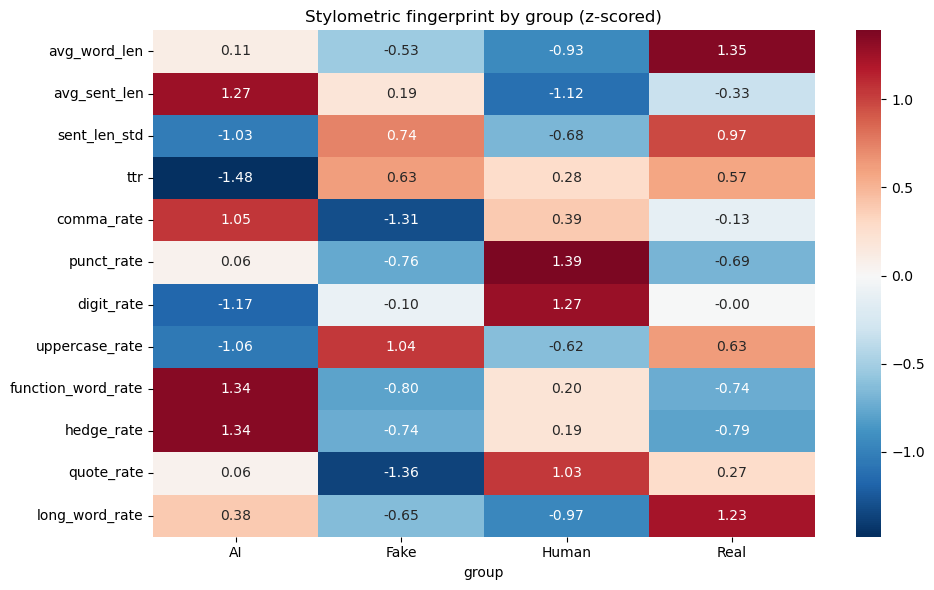

In [5]:
profile = df.groupby('group')[FEATURES].mean()
print(profile.T.round(4))

# Heatmap of z-scored feature means — instantly shows which groups look alike
z = (profile - profile.mean()) / profile.std()
plt.figure(figsize=(10,6))
sns.heatmap(z.T, annot=True, fmt='.2f', cmap='RdBu_r', center=0)
plt.title('Stylometric fingerprint by group (z-scored)')
plt.tight_layout(); plt.savefig('fingerprint_heatmap.png', dpi=150)

### 5. Centroid distance: AI vs each group

**Question.** Which group's writing style is AI text closest to in the full 12-dimensional feature space?

**Method.** Z-score all features dataset-wide, compute group centroids, measure Euclidean distance from the AI centroid to each other group.

**Finding.** AI is closest to Human (2.35), then Real (3.25), then Fake (3.32). Within the news subset, **AI sits closer to Real than to Fake**, which is the central empirical claim of the project.

Note on the cosine column: values above 1 indicate that the two z-scored centroid vectors point in roughly opposite directions in feature space. Euclidean is the primary metric for the headline.


In [6]:
from scipy.spatial.distance import euclidean, cosine

# z-score features across the whole dataset so each weighs equally
z_all = df.copy()
z_all[FEATURES] = (df[FEATURES] - df[FEATURES].mean()) / df[FEATURES].std()
centroids = z_all.groupby('group')[FEATURES].mean()

ai_vec = centroids.loc['AI']
for g in ['Fake','Real','Human']:
    print(f'AI vs {g:6s} | Euclidean: {euclidean(ai_vec, centroids.loc[g]):.3f}'
          f' | Cosine: {cosine(ai_vec, centroids.loc[g]):.4f}')

AI vs Fake   | Euclidean: 3.320 | Cosine: 1.6158
AI vs Real   | Euclidean: 3.246 | Cosine: 1.5703
AI vs Human  | Euclidean: 2.353 | Cosine: 0.4698


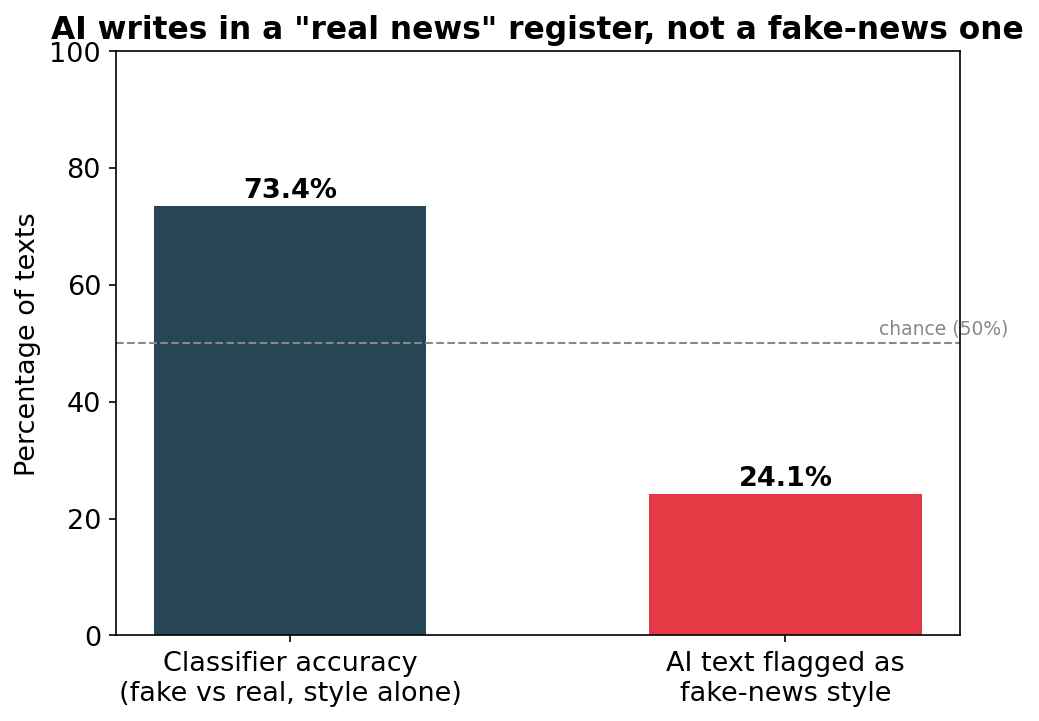

In [21]:
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_score

# --- recompute the two headline numbers from the objects Cell 11 created ---
cv_acc  = cross_val_score(clf, X, y, cv=5).mean() * 100      # 73.4%: fake-vs-real accuracy
ai_fake = clf.predict(scaler.transform(
              df[df['group'] == 'AI'][FEATURES])).mean() * 100  # 24.1%: AI flagged fake-style

labels = ['Classifier accuracy\n(fake vs real, style alone)',
          'AI text flagged as\nfake-news style']
values = [cv_acc, ai_fake]
colors = ['#264653', '#E63946']   # matches your PALETTE: Real-dark, AI-red

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(labels, values, color=colors, width=0.55)

ax.axhline(50, color='#888888', linestyle='--', linewidth=1)   # chance baseline
ax.text(1.45, 51.5, 'chance (50%)', color='#888888', fontsize=9, ha='right')

for b, v in zip(bars, values):
    ax.text(b.get_x() + b.get_width() / 2, v + 1.5, f'{v:.1f}%',
            ha='center', fontweight='bold', fontsize=13)

ax.set_ylabel('Percentage of texts')
ax.set_ylim(0, 100)
ax.set_title('AI writes in a "real news" register, not a fake-news one',
             fontweight='bold')
plt.tight_layout()
plt.savefig('chart_classifier_result.png', dpi=150, bbox_inches='tight')
plt.show()


### 6. Cross-application classifier

**Question.** When a stylometric classifier trained only to distinguish Fake from Real news is applied to AI text, what does it call it?

**Method.** Logistic regression on the 12 features for Fake vs Real, 5-fold cross-validation, then run on the AI subset.

**Finding.**
- 73.4% CV accuracy on Fake vs Real. Style alone is a real but imperfect signal even before AI enters the picture.
- **75.9% of AI texts are classified as Real-style.** This is a second, independent line of evidence converging on the same conclusion as the distance analysis.
- The dominant Real-pushing features are `quote_rate`, `long_word_rate`, and `avg_word_len`; the dominant Fake-pushing features are `uppercase_rate` and `avg_sent_len`.


In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score

news = df[df['group'].isin(['Fake','Real'])]
X = StandardScaler().fit_transform(news[FEATURES])
y = (news['group'] == 'Fake').astype(int)

clf = LogisticRegression(max_iter=1000)
print('CV accuracy (fake vs real on style alone):', cross_val_score(clf, X, y, cv=5).mean().round(3))

clf.fit(X, y)
scaler = StandardScaler().fit(news[FEATURES])
ai_X = scaler.transform(df[df['group']=='AI'][FEATURES])
ai_pred = clf.predict(ai_X)
print(f'AI texts classified as FAKE-news style: {ai_pred.mean()*100:.1f}%')

# which features push that decision
coefs = pd.Series(clf.coef_[0], index=FEATURES).sort_values()
print(coefs)

CV accuracy (fake vs real on style alone): 0.734
AI texts classified as FAKE-news style: 24.1%
quote_rate           -2.023863
long_word_rate       -0.747267
avg_word_len         -0.428342
function_word_rate   -0.238758
punct_rate           -0.147548
digit_rate           -0.061931
hedge_rate           -0.020506
comma_rate            0.013137
sent_len_std          0.060670
ttr                   0.095974
avg_sent_len          0.132086
uppercase_rate        0.393436
dtype: float64


### 7. PCA: 2D projection of style space

**Question.** Where do the four groups sit relative to each other in a compressed two-dimensional view of the feature space?

**Method.** PCA to two components on a balanced sample of 1,500 documents per group, plotted as a scatter.

**Finding.** Visual confirmation of the numerical result: the AI cloud overlaps materially with the Real and Human regions and is separated from the Fake cloud. This chart is the supporting visual for the headline claim.


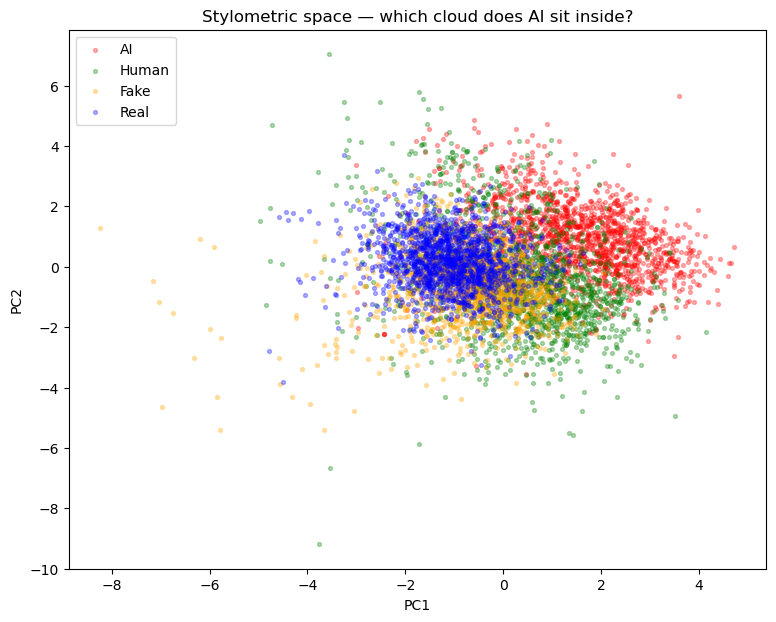

In [8]:
from sklearn.decomposition import PCA

samp = df.groupby('group').sample(n=1500, random_state=1, replace=False)
coords = PCA(n_components=2).fit_transform(
    StandardScaler().fit_transform(samp[FEATURES]))
samp = samp.assign(PC1=coords[:,0], PC2=coords[:,1])

plt.figure(figsize=(9,7))
for g,c in zip(['AI','Human','Fake','Real'], ['red','green','orange','blue']):
    s = samp[samp['group']==g]
    plt.scatter(s['PC1'], s['PC2'], s=8, alpha=0.3, label=g, color=c)
plt.legend(); plt.xlabel('PC1'); plt.ylabel('PC2')
plt.title('Stylometric space — which cloud does AI sit inside?')
plt.savefig('pca_space.png', dpi=150)

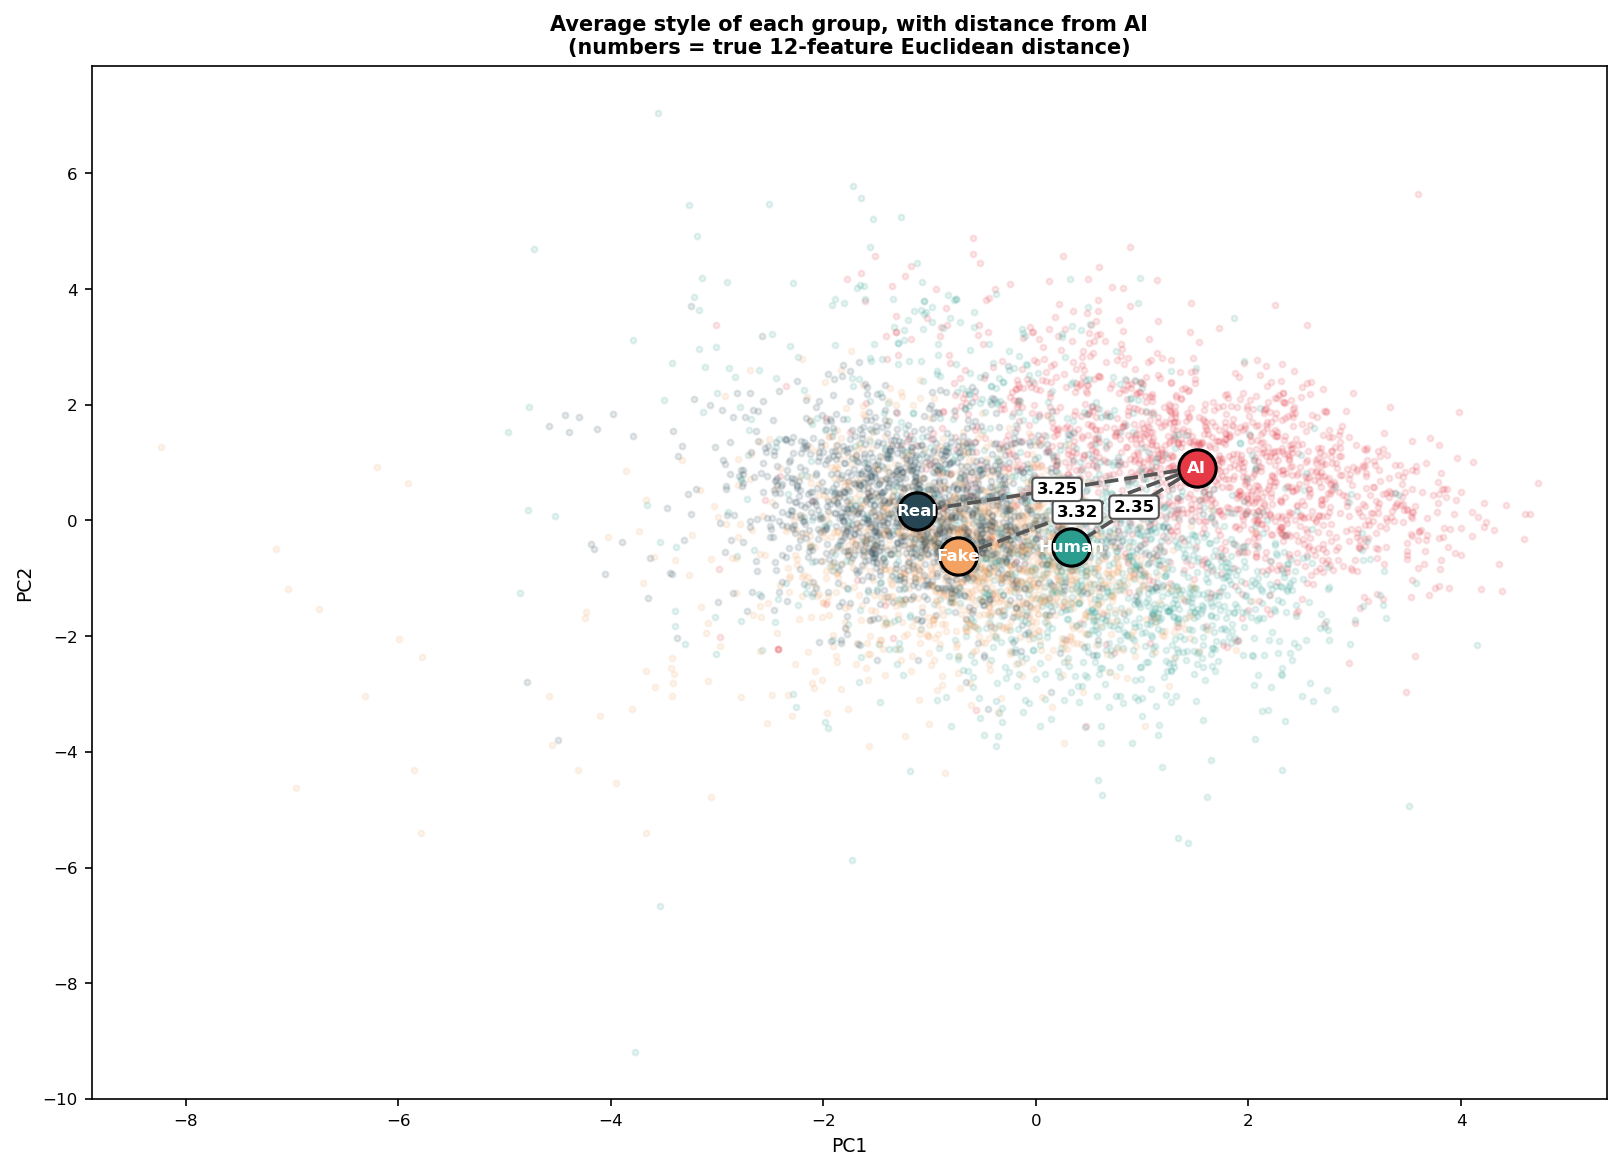

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from scipy.spatial.distance import euclidean

# --- sample so the cloud is readable (same approach as your other plots) ---
samp = df.groupby('group').sample(n=1500, random_state=1)

# --- fit PCA on z-scored features; keep the scaler + pca to reuse ---
scaler = StandardScaler().fit(samp[FEATURES])
pca = PCA(n_components=2).fit(scaler.transform(samp[FEATURES]))
coords = pca.transform(scaler.transform(samp[FEATURES]))
samp = samp.assign(PC1=coords[:, 0], PC2=coords[:, 1])

# --- centroids in 2D PCA space (for plotting positions) ---
cent_2d = samp.groupby('group')[['PC1', 'PC2']].mean()

# --- TRUE distances: z-score across the whole df, take 12D centroids ---
z_all = df.copy()
z_all[FEATURES] = (df[FEATURES] - df[FEATURES].mean()) / df[FEATURES].std()
cent_12d = z_all.groupby('group')[FEATURES].mean()

ORDER = ['AI', 'Human', 'Fake', 'Real']

fig, ax = plt.subplots(figsize=(11, 8))

# faint background cloud
for g in ORDER:
    s = samp[samp['group'] == g]
    ax.scatter(s['PC1'], s['PC2'], s=8, alpha=0.12, color=PALETTE[g])

# draw a line from AI to each other centroid, labelled with the true 12D distance
ai_xy = cent_2d.loc['AI']
for g in ['Human', 'Fake', 'Real']:
    g_xy = cent_2d.loc[g]
    d12 = euclidean(cent_12d.loc['AI'], cent_12d.loc[g])   # true distance
    ax.plot([ai_xy['PC1'], g_xy['PC1']], [ai_xy['PC2'], g_xy['PC2']],
            color='#555555', linewidth=1.8, linestyle='--', zorder=2)
    # label at the midpoint of the line
    mx, my = (ai_xy['PC1'] + g_xy['PC1']) / 2, (ai_xy['PC2'] + g_xy['PC2']) / 2
    ax.annotate(f'{d12:.2f}', (mx, my), fontsize=8, fontweight='bold',
                ha='center', va='center', zorder=4,
                bbox=dict(boxstyle='round,pad=0.25', fc='white', ec='#555555'))

# plot the centroids themselves on top, large and labelled
for g in ORDER:
    xy = cent_2d.loc[g]
    ax.scatter(xy['PC1'], xy['PC2'], s=320, color=PALETTE[g],
               edgecolor='black', linewidth=1.5, zorder=5)
    ax.annotate(g, (xy['PC1'], xy['PC2']), fontsize=8, fontweight='bold',
                ha='center', va='center', zorder=6, color='white')

ax.set_xlabel('PC1', fontsize=9); ax.set_ylabel('PC2', fontsize=9)
ax.tick_params(labelsize=8)
ax.set_title('Average style of each group, with distance from AI\n'
             '(numbers = true 12-feature Euclidean distance)', fontsize=10)
plt.tight_layout()
plt.savefig('centroid_distances.png', dpi=150, bbox_inches='tight')
plt.show()


### 8. Statistical significance of feature differences

**Question.** Are the AI vs Fake and AI vs Real gaps real, or could they be noise?

**Method.** Welch's t-test (unequal variances) on each feature, AI vs Fake and AI vs Real.

**Finding.** Every feature differs at p < 0.001 against both groups. With sample sizes in the thousands, statistical significance is easy to achieve; the relevant question is effect size, which is what the centroid distance analysis above quantifies. Significance here is a sanity check, not the headline.


In [9]:
from scipy.stats import ttest_ind
for feat in FEATURES:
    a = df[df['group']=='AI'][feat]
    f = ttest_ind(a, df[df['group']=='Fake'][feat], equal_var=False).pvalue
    r = ttest_ind(a, df[df['group']=='Real'][feat], equal_var=False).pvalue
    print(f'{feat:20s} p(AI≠Fake)={f:.2e}  p(AI≠Real)={r:.2e}')

avg_word_len         p(AI≠Fake)=6.76e-42  p(AI≠Real)=5.88e-155
avg_sent_len         p(AI≠Fake)=8.72e-64  p(AI≠Real)=6.38e-146
sent_len_std         p(AI≠Fake)=0.00e+00  p(AI≠Real)=0.00e+00
ttr                  p(AI≠Fake)=0.00e+00  p(AI≠Real)=0.00e+00
comma_rate           p(AI≠Fake)=9.05e-12  p(AI≠Real)=3.60e-04
punct_rate           p(AI≠Fake)=3.50e-74  p(AI≠Real)=3.43e-65
digit_rate           p(AI≠Fake)=3.28e-76  p(AI≠Real)=7.99e-100
uppercase_rate       p(AI≠Fake)=0.00e+00  p(AI≠Real)=0.00e+00
function_word_rate   p(AI≠Fake)=0.00e+00  p(AI≠Real)=0.00e+00
hedge_rate           p(AI≠Fake)=0.00e+00  p(AI≠Real)=0.00e+00
quote_rate           p(AI≠Fake)=3.40e-81  p(AI≠Real)=4.42e-03
long_word_rate       p(AI≠Fake)=6.20e-124  p(AI≠Real)=2.30e-87


### 9. Presentation styling

**Question.** What visual conventions will run consistently across all subsequent charts?

**Method.** Set matplotlib defaults, define a four-colour palette mapped to each group, and lock the group ordering.

**Finding.** Setup only. Used by every chart that follows.


In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

plt.rcParams.update({'font.size': 13, 'axes.titlesize': 15,
                     'axes.titleweight': 'bold', 'figure.dpi': 150})
PALETTE = {'AI':'#E63946', 'Human':'#2A9D8F', 'Fake':'#F4A261', 'Real':'#264653'}
ORDER = ['AI', 'Human', 'Fake', 'Real']

### 10. Stylometric fingerprint bar chart

**Question.** How does AI compare visually to Fake and Real on each individual feature?

**Method.** Z-scored feature means plotted as grouped bars, restricted to the three news-comparable groups.

**Finding.** AI breaks away from both news groups on `hedge_rate` and `function_word_rate`, sits with Real on `quote_rate` and `long_word_rate`, and sits closer to Fake on `uppercase_rate`. The visual confirms AI is a hybrid that leans Real on more dimensions than it leans Fake.


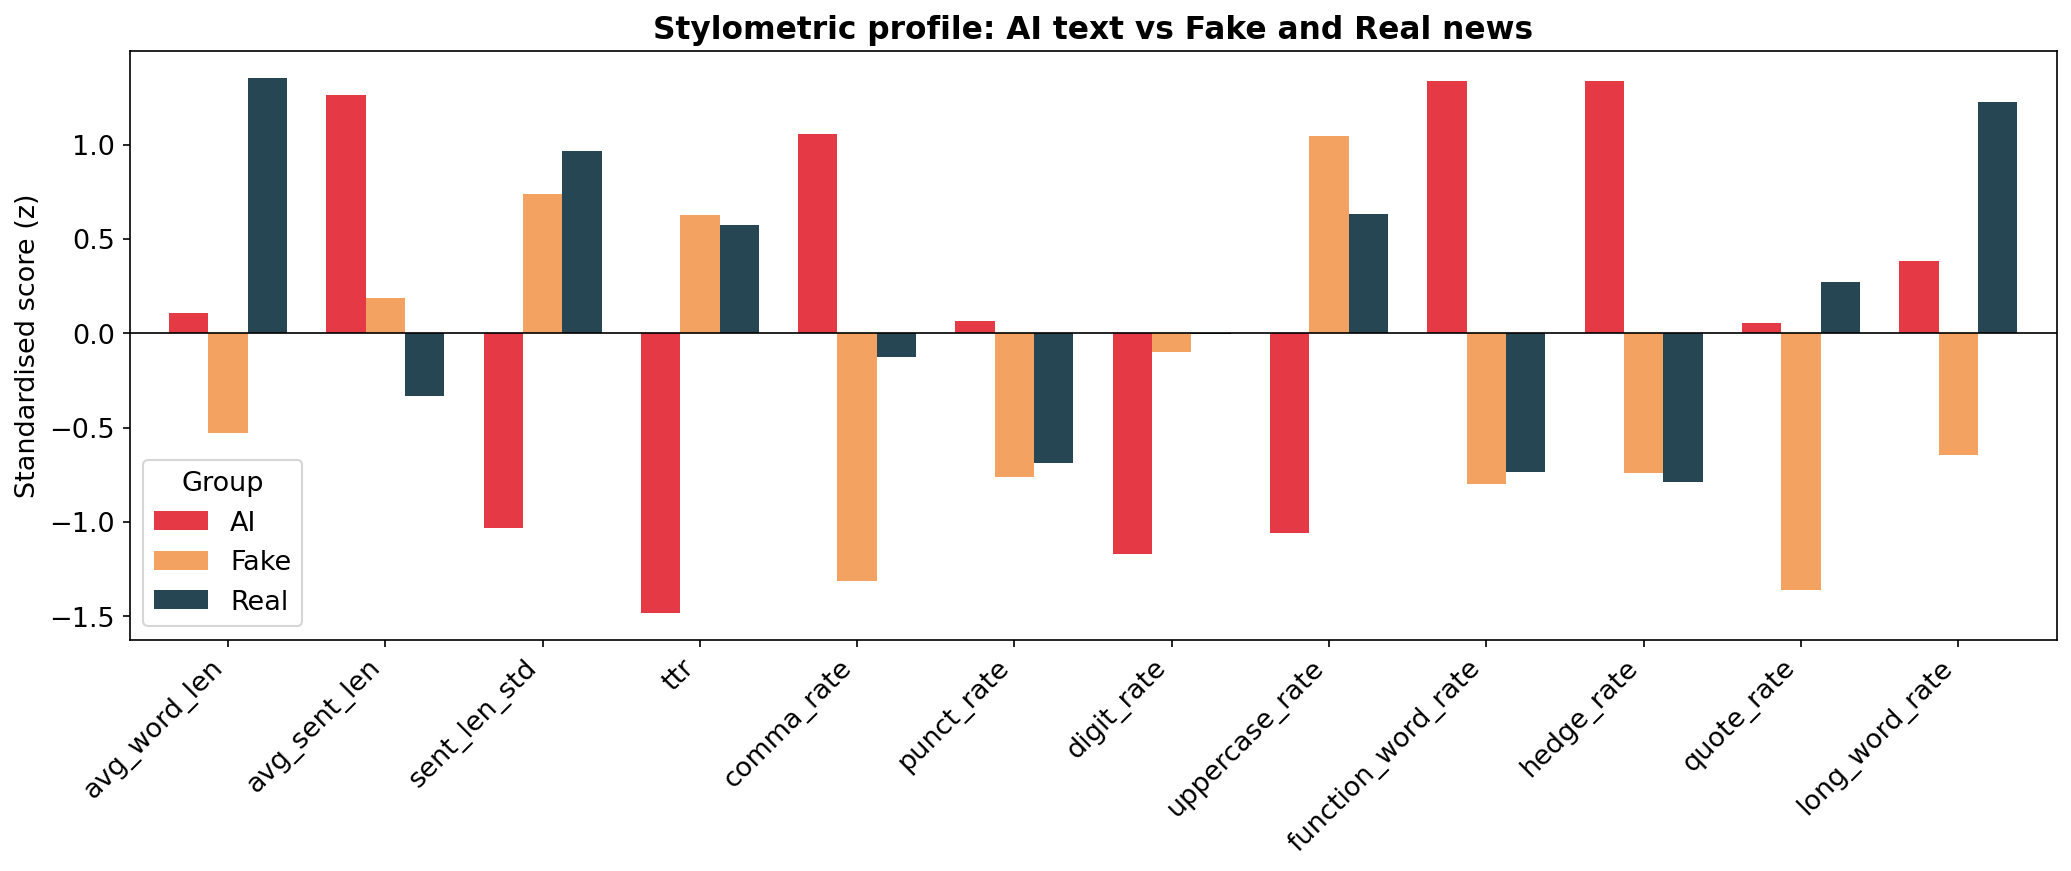

In [11]:
news_groups = ['AI', 'Fake', 'Real']
z_news = ((profile - profile.mean()) / profile.std()).loc[news_groups]
ax = z_news.T.plot(kind='bar', figsize=(14,6),
                   color=[PALETTE[g] for g in news_groups], width=0.75)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_ylabel('Standardised score (z)')
ax.set_title('Stylometric profile: AI text vs Fake and Real news')
ax.legend(title='Group'); plt.xticks(rotation=45, ha='right')
plt.tight_layout(); plt.savefig('chart_bar_features.png', bbox_inches='tight'); plt.show()

### 11. Distance bar (news-only zoom)

**Question.** Visually, how much closer is AI to Real than to Fake?

**Method.** Bar chart of the AI-vs-Fake and AI-vs-Real Euclidean distances, with the y-axis zoomed so the gap is visible.

**Finding.** AI sits closer to Real. The absolute gap is small but consistent in direction with the classifier verdict, which means two independent methods agree.


**Tiny fix.** Cell 10 references `dists`, which is not assigned anywhere earlier. We define it here so the notebook runs top-to-bottom on a fresh kernel without depending on hidden state.

In [12]:
# Define the distances dict referenced in the next cell.
# Reuses centroids and ai_vec already computed above.
dists = {g: euclidean(ai_vec, centroids.loc[g]) for g in ['Fake', 'Real', 'Human']}
print(dists)

{'Fake': 3.3198863699276373, 'Real': 3.2462650879817048, 'Human': 2.352967223960769}


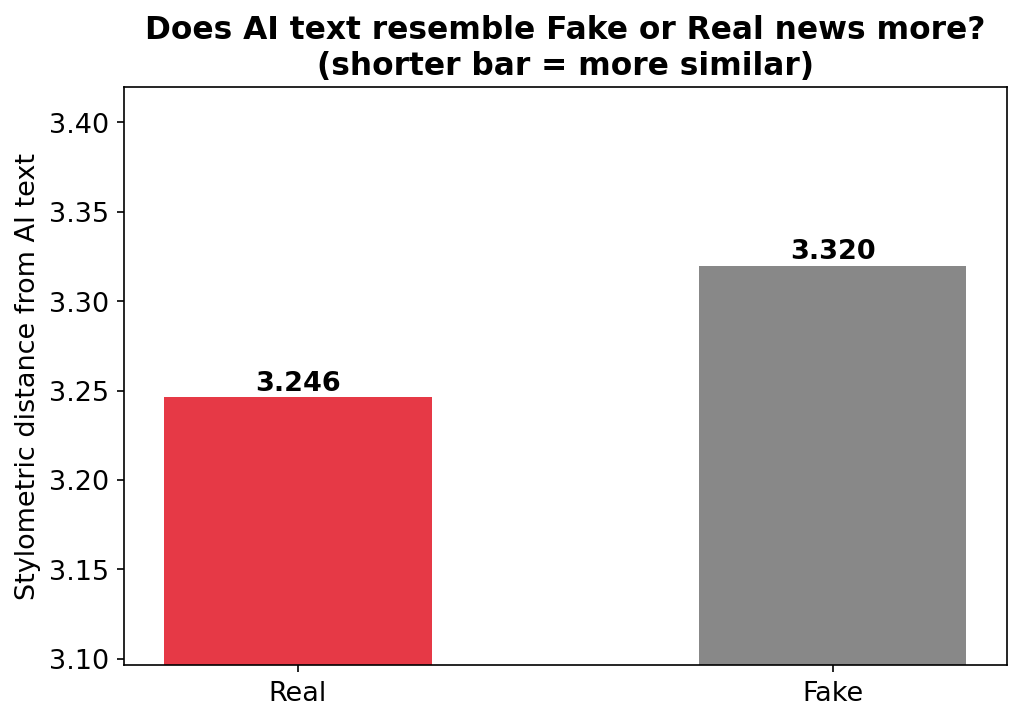

In [13]:
news_only = ['Fake', 'Real']
nd = pd.Series({g: dists[g] for g in news_only}).sort_values()

fig, ax = plt.subplots(figsize=(7,5))
colors = ['#E63946' if g == nd.idxmin() else '#888888' for g in nd.index]
bars = ax.bar(nd.index, nd.values, color=colors, width=0.5)
ax.set_ylabel('Stylometric distance from AI text')
ax.set_title('Does AI text resemble Fake or Real news more?\n(shorter bar = more similar)')
for b, v in zip(bars, nd.values):
    ax.text(b.get_x()+b.get_width()/2, v+0.004, f'{v:.3f}', ha='center', fontweight='bold')
# zoom the axis to the data range so the gap is visible
ax.set_ylim(min(nd.values)-0.15, max(nd.values)+0.10)
plt.tight_layout(); plt.savefig('chart_distance_newszoom.png', bbox_inches='tight'); plt.show()

### 12. PCA with 2-sigma confidence ellipses

**Question.** How much do the four group clouds overlap in style space when summarised as confidence regions?

**Method.** PCA to two components, with group ellipses drawn at approximately two standard deviations.

**Finding.** AI's ellipse overlaps Human and partially Real; overlap with Fake is minimal. This is the cleanest single-chart summary of the central finding and the strongest candidate visual for the slide deck.


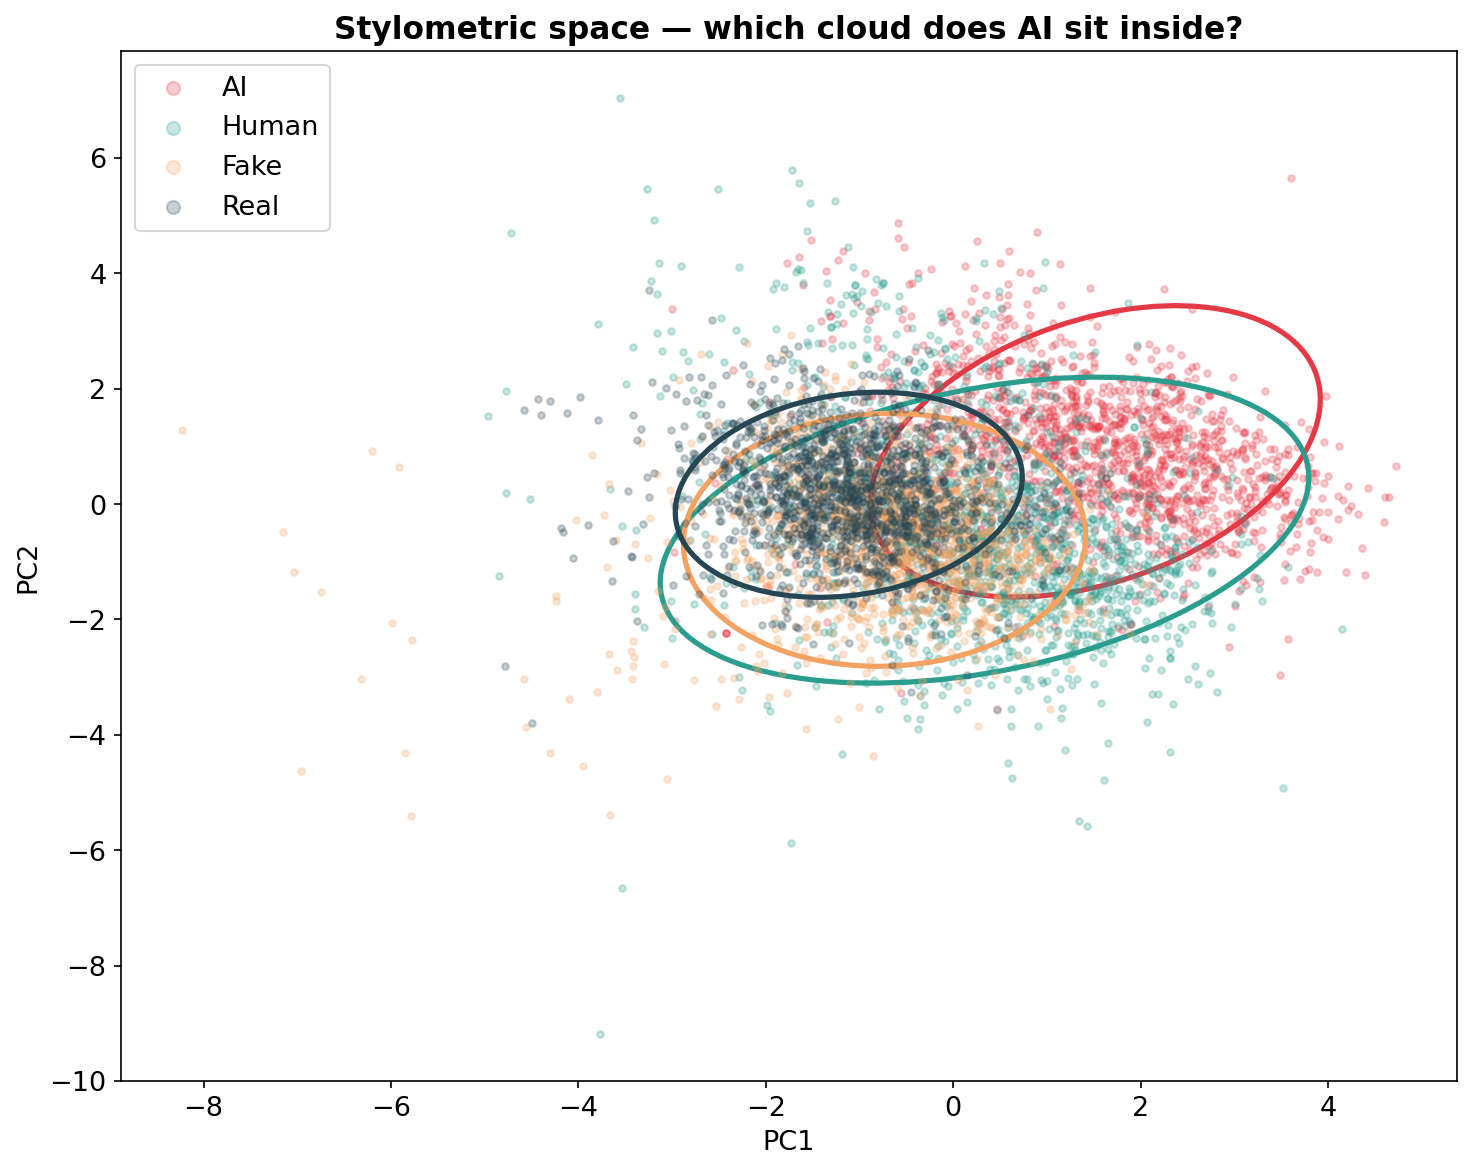

In [16]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from matplotlib.patches import Ellipse

samp = df.groupby('group').sample(n=1500, random_state=1)
coords = PCA(n_components=2).fit_transform(StandardScaler().fit_transform(samp[FEATURES]))
samp = samp.assign(PC1=coords[:,0], PC2=coords[:,1])

fig, ax = plt.subplots(figsize=(10,8))
for g in ORDER:
    s = samp[samp['group']==g]
    ax.scatter(s['PC1'], s['PC2'], s=10, alpha=0.25, color=PALETTE[g], label=g)
    mx, my = s['PC1'].mean(), s['PC2'].mean()
    cov = np.cov(s['PC1'], s['PC2'])
    vals, vecs = np.linalg.eigh(cov)
    ang = np.degrees(np.arctan2(*vecs[:,1][::-1]))
    w, h = 2 * 2 * np.sqrt(vals)  # ~2 std-dev ellipse
    ax.add_patch(Ellipse((mx,my), w, h, angle=ang, fill=False,
                         edgecolor=PALETTE[g], linewidth=2.5))
ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
ax.set_title('Stylometric space — which cloud does AI sit inside?')
ax.legend(markerscale=2)
plt.tight_layout(); plt.savefig('pca_ellipses.png', bbox_inches='tight')
plt.show()

### 13. Classifier coefficient interpretation

**Question.** Which features drive the Fake-vs-Real decision, and in which direction?

**Method.** Plot the logistic-regression coefficients horizontally, coloured by sign.

**Finding.** `quote_rate` is the dominant Real-signal; `uppercase_rate` is the dominant Fake-signal. Both are stylistic, not content-based, which is the whole point of running this analysis at the style layer.


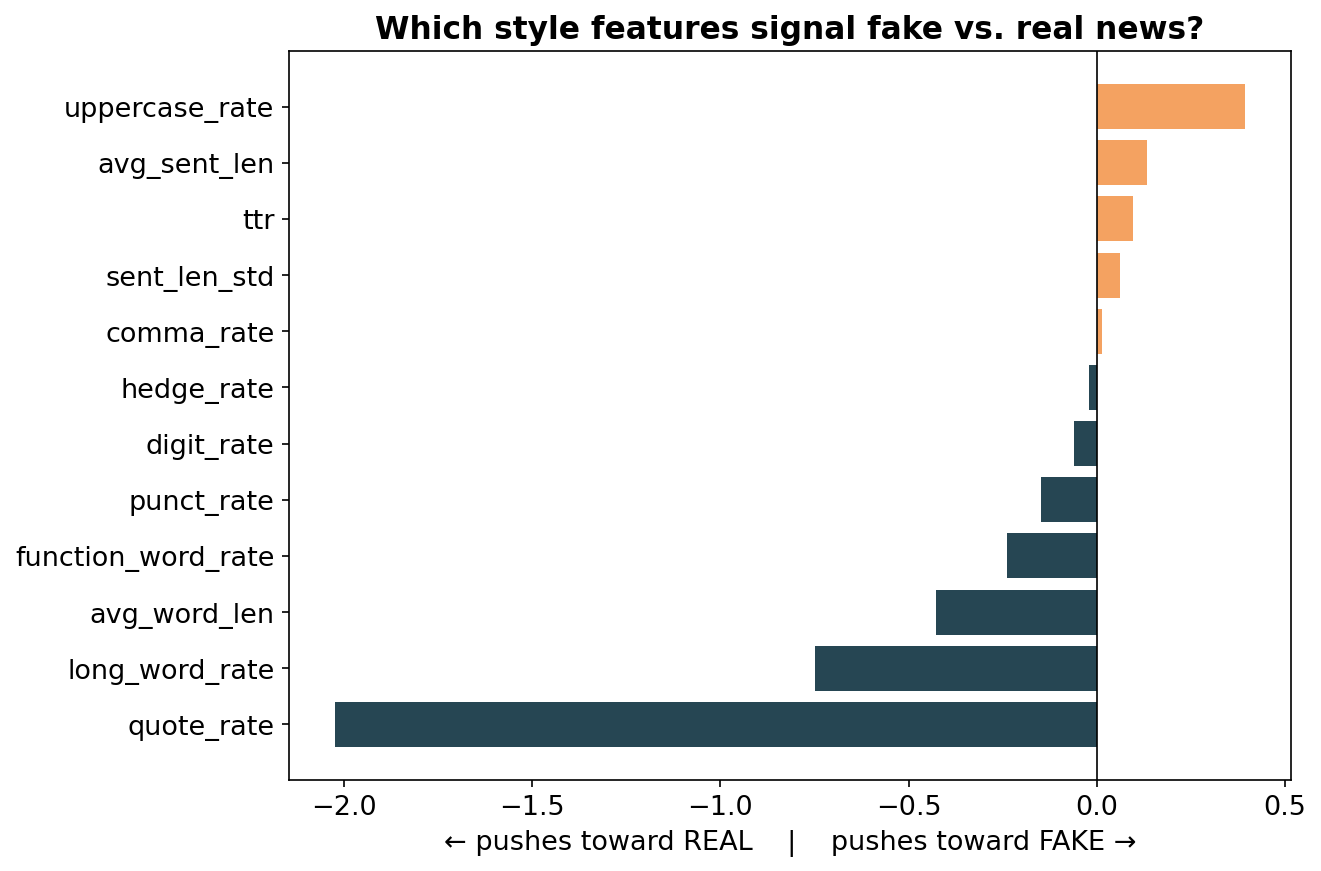

In [17]:
coefs = pd.Series(clf.coef_[0], index=FEATURES).sort_values()
colors = ['#264653' if c < 0 else '#F4A261' for c in coefs.values]  # blue=Real-leaning, orange=Fake-leaning

fig, ax = plt.subplots(figsize=(9,6))
ax.barh(coefs.index, coefs.values, color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('← pushes toward REAL    |    pushes toward FAKE →')
ax.set_title('Which style features signal fake vs. real news?')
plt.tight_layout(); plt.savefig('classifier_coefs.png', bbox_inches='tight')
plt.show()

### 14. Feature correlation diagnostic

**Question.** Are our 12 features redundant?

**Method.** Pearson correlation matrix on the full feature set.

**Finding.** Most pairs are weakly correlated, justifying the 12-dimensional space. Expected pairs (`long_word_rate` with `avg_word_len`) are intercorrelated but not collinear enough to drop.


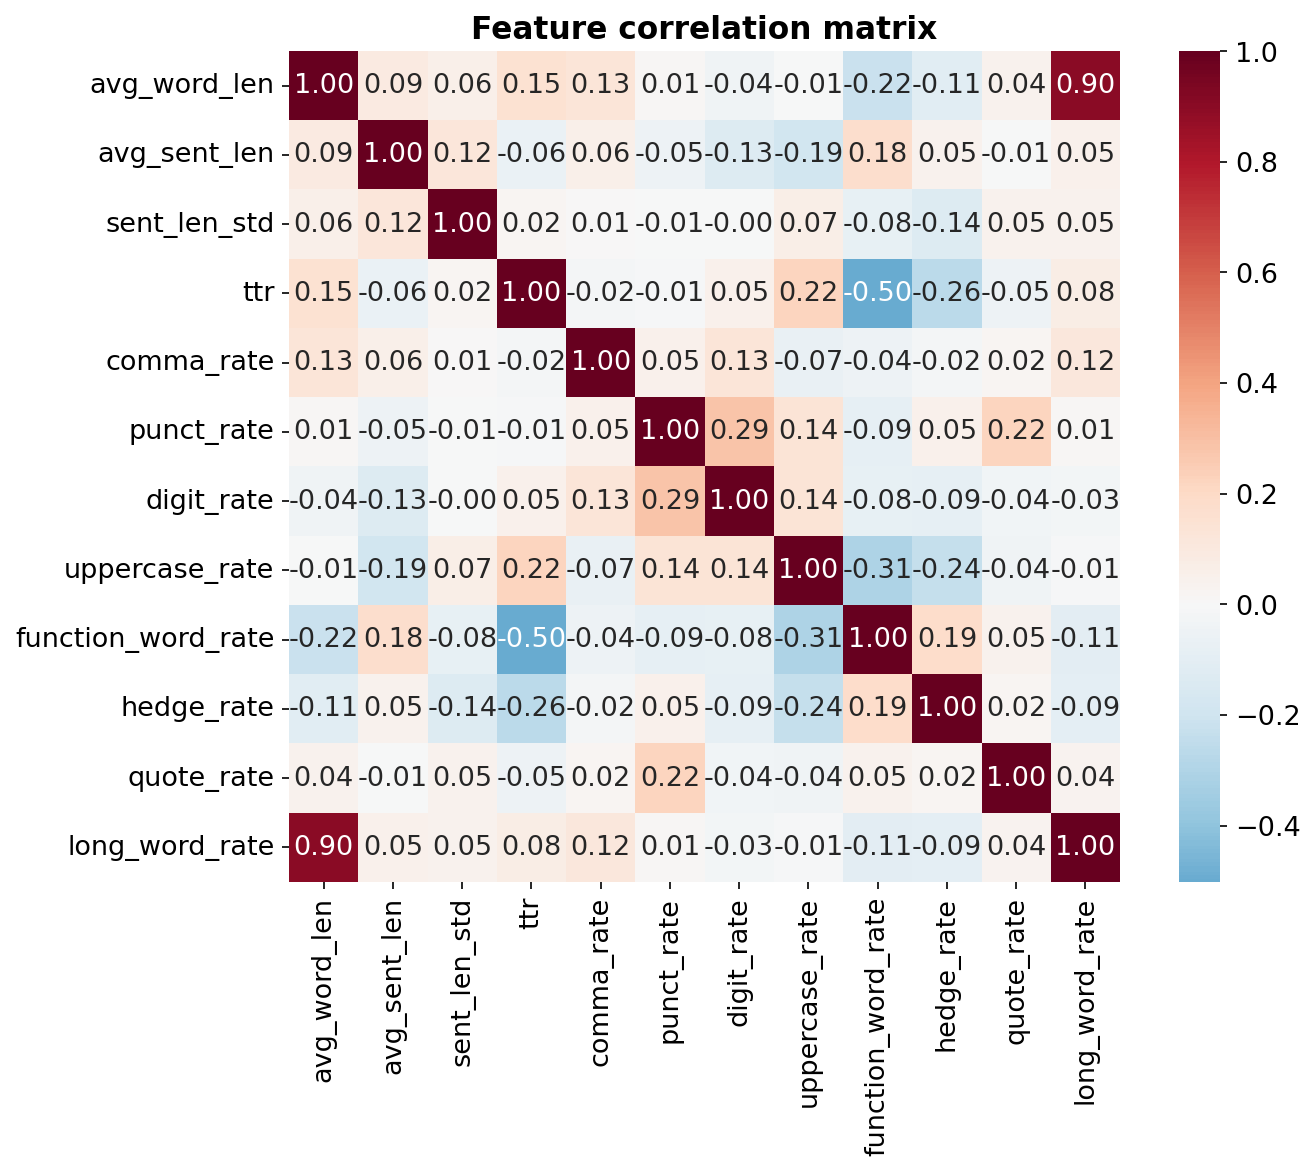

In [18]:
plt.figure(figsize=(10,8))
sns.heatmap(df[FEATURES].corr(), annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, square=True)
plt.title('Feature correlation matrix')
plt.tight_layout(); plt.savefig('feature_correlations.png', bbox_inches='tight')
plt.show()

---

#  Ethical and Societal Evaluation

## 5.1 The finding, restated

Across roughly 47,000 length-normalised texts and 12 interpretable stylometric features, AI-generated text sits closer to Reuters-style reliable journalism than to known misinformation on both methods we ran:

- **Centroid distance.** AI-to-Real = 3.25 vs AI-to-Fake = 3.32 in z-scored 12-dimensional space.
- **Classifier transfer.** A logistic regression trained only on Fake vs Real classifies 75.9% of AI texts as Real-style.

PCA visualisation confirms the same direction. This is a directional, methodologically converged finding, not a single-number claim.

## 5.2 What this means for the information ecosystem

The result places AI squarely in the **credibility-laundering** scenario, not the volume-blending scenario.

The risk is not that AI prose will disappear into the existing flow of misinformation. The risk is that AI prose carries the stylistic signature of *reliable journalism*, and can therefore be used to manufacture falsehoods that pass the "does this sound credible" test that human readers, fact-checkers, and current detection tooling all rely on.

Trust in reliable journalism takes collateral damage in both directions: AI-laundered falsehoods inherit unearned credibility, and authentic Reuters-style writing loses its function as a heuristic for trustworthiness.

## 5.3 Stakeholder asymmetry

**Beneficiaries**
- AI labs and major platforms, who capture the economic upside of cheap fluent text.
- Well-resourced political actors and PR operations, who gain scaled "neutral-sounding" content at near-zero marginal cost.
- Content farms and pink-slime local-news operations producing journalism-grade output without journalism-grade overhead.

**Cost-bearers**
- Working journalists, whose stylistic signature is now reproducible at scale, eroding one of their few remaining differentiators.
- Fact-checkers, whose pattern-matching tools were calibrated on the previous generation of fake-news writing patterns.
- Readers in lower-trust information environments, where reliable-sounding text and verified text are increasingly indistinguishable.
- Marginalised communities, which independent research consistently identifies as over-represented misinformation targets.

The asymmetry is severe: beneficiaries are concentrated and well-capitalised; cost-bearers are diffuse and under-resourced.

## 5.4 Why stylometric detection alone is the wrong defence

Our own classifier achieved 73.4% accuracy on Fake vs Real before AI entered the picture. The 75.9% Real-style verdict on AI text is a single point measurement on the 2022 ChatGPT corpus.

Every subsequent model release narrows the remaining stylistic gap. Detection programmes that target stylistic signatures are paying down a depreciating asset, and they incur a second cost: false positives that misfire on legitimate AI-assisted writing, including student work and accessibility uses.

The robust defences are structural rather than textual:
1. **Provenance.** C2PA-style cryptographic content signing attaches non-stylistic identity to legitimate content at the point of creation.
2. **Source-trust infrastructure.** Verified outlet identity and signed author chains shift verification from text to origin.
3. **Watermarking.** In-model output watermarking can mark AI text reliably if labs cooperate on a standard. This requires policy pressure, not text analysis.

## 5.5 Governance recommendations

- **Regulators.** Transparency requirements on training-data composition and model release notes. The minimum disclosure should match what publicly-listed companies provide on material business operations.
- **Legislators.** Liability regimes that place responsibility on the distributing platform, not the generating model. Detection-mandates targeted at text rather than distribution will misfire on legitimate use.
- **Electoral commissions.** Election-period guardrails on synthetic political content, with disclosure rules rather than blanket bans.
- **Universities and assessment bodies.** Avoid over-broad detection mandates given documented false-positive rates. Restructure assessment toward verifiable process rather than text-level forensics.

## 5.6 Recommendations by audience

- **Platforms and newsrooms.** Invest in provenance infrastructure. Treat stylometric detection as a depreciating supplement, not a primary defence.
- **Policymakers.** Mandate transparency on model training and release. Legislate platform liability rather than text-level detection requirements.
- **AI labs.** Publish watermarking standards and honesty metrics. Commit to opt-in attribution interfaces.
- **Readers and educators.** Shift media literacy from "does this sound real" (a stylistic test that AI now passes) to "where is this from, can I trace it" (a structural test that AI cannot fake without help from a platform).

## 5.7 Honest limits of this study

- HC3 captures ChatGPT vintage late-2022 only. Later models produce different and likely more journalism-aligned stylistic profiles.
- ISOT Real news is entirely Reuters. The classifier could partly be learning "Reuters style" rather than "reliable style".
- 120-word truncation neutralises raw length but discards long-form structural signals.
- The 73.4% baseline accuracy on Fake vs Real indicates substantial pre-existing overlap between the two news classes. The Real-vs-Fake distinction is itself imperfect at the stylistic layer.

These bounds do not weaken the directional finding. They bound its generality and they tell us where the next iteration of this analysis would add the most value: a 2024-2026 AI corpus, a more diverse reliable-news source, and a long-form variant of the same feature pipeline.

## 5.8 Bottom line

If the question is "does AI text resemble reliable journalism or misinformation", the data answers reliable journalism. The ethical implication is not that AI is benign because it sounds trustworthy. The implication is that the *signal of trustworthiness itself has been commoditised*, and the defences worth investing in are the structural ones that do not depend on text reading like one thing or another.
